# A Physics-Informed Neural Network approach for compartmental epidemiological models


Notebooks for PINN solution of the SIR compartmental model presented [in the paper](https://arxiv.org/abs/2311.09944):

```
@misc{millevoi2023physicsinformed,
      title={A Physics-Informed Neural Network approach for compartmental epidemiological models}, 
      author={Caterina Millevoi and Damiano Pasetto and Massimiliano Ferronato},
      year={2023},
      eprint={2311.09944},
      archivePrefix={arXiv},
      primaryClass={math.NA}
}
```

Note: The uploaded code is related to Case 1. For further information please contact the corresponding author.

In [ ]:
import sciann as sn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy.integrate import odeint

## Case 1: constant trasmission rate

In [ ]:
# SIR 模型，Case 1：常数传播率
# 参数 N 表示总人口，delta 表示平均感染期的倒数，r0 表示基本再生数
# beta = delta * r0，因此 r0 = beta / delta
# C 用于把 S/I/R 做尺度归一化，这里按 10^6 人口量级处理
N     = 56e6 # (-) population (Italy)
delta = 1/5  # (1/T) 5 = mean reproduction period 
r0    = 3.   # (-) basic reproduction number (estimate for Italy) 

beta = delta*r0 # (1/T) transmission rate 
t0   = 0.       # (days) initial time
tf = 90.        # (days) final time

# 缩放因子：对应Eq. (6)
C = 1e5  # 缩放因子，按人口量级选取，便于 PINN 训练；C 的选择会影响训练稳定性和收敛速度
C1 = tf*C/N  # 对应论文 Eq. (6) 中的 C1 = tf*C/N，表示时间和人数的联合缩放因子
C2 = tf*delta # 对应论文 Eq. (6) 中的 C2 = tf*delta，表示时间和感染期的联合缩放因子


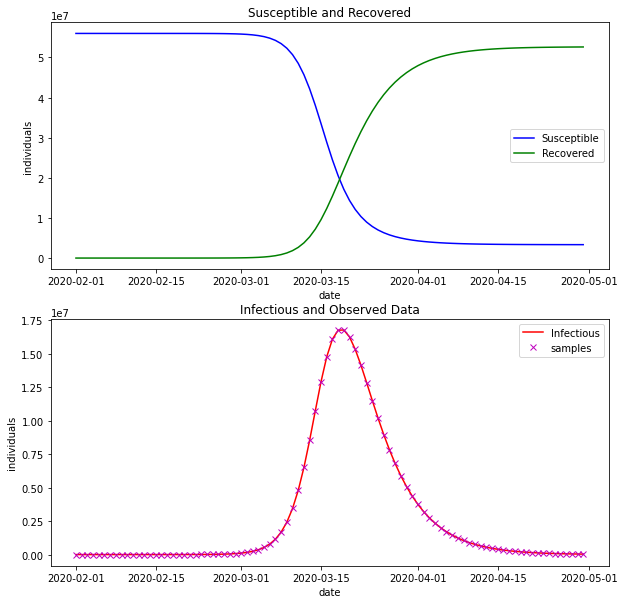

In [ ]:
# 下面定义 SIR 常微分方程，对应论文 Eq. (1)-(2)
# dS/dt = -lambda*S, dI/dt = lambda*S - delta*I, dR/dt = delta*I
# lambda_val = beta * I / N，表示感染力项 beta*I/N
def SIR(x, t, delta, beta, N, t0):
    S, I, R = x
    lambda_val = beta*I/N;
    dSdt = -lambda_val*S
    dIdt = lambda_val*S - delta*I
    dRdt = delta*I
    return [dSdt, dIdt, dRdt]

# Initial conditions
# 初始条件设为 S(t0)=N-I0, I(t0)=I0, R(t0)=0，对应论文 Eq. (2)
# 这里取 I0=1，表示一次初始暴发
S0 = N-1
I0 = 1
R0 = 0
x0 = [S0, I0, R0]

# Time span
# PINN 的时间变量按 t_s = (t - t0)/(tf - t0) 归一化
timespan = np.arange('2020-02-01', '2020-05-01', dtype='datetime64[D]')
tspan = timespan.astype(int)

# 用 ODE 解生成时间序列和参考数据
# 根据 SIR 这个变化率函数，从初始值 x0 出发，数值积分得到的 S(t), I(t), R(t) 在 tspan 各个时间点上的值。
x = odeint(SIR, x0, tspan, args=(delta, beta, N, tspan[0]))

S_data = x[:, 0]
I_data = x[:, 1]
R_data = x[:, 2]

# Generate observations
# 观测数据 I_obs 是对 I_data 的泊松采样: 在固定时间段内，某类事件发生了多少次。
# 也就是说，假设 ODE 解出来的 I_data(t) 是某一天感染人数的“期望值”，真实观测到的 I_obs(t) 会围绕这个值随机波动。
I_obs = np.random.poisson(I_data)

# Plot results
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(timespan, S_data, 'b', label='Susceptible')
plt.plot(timespan, R_data, 'g', label='Recovered')
plt.legend()
plt.xlabel('date')
plt.ylabel('individuals')
plt.title('Susceptible and Recovered')
plt.subplot(2, 1, 2)
plt.plot(timespan, I_data, 'r', label='Infectious')
plt.plot(timespan, I_obs, 'xm', label='samples')
plt.legend()
plt.xlabel('date')
plt.ylabel('individuals')
plt.title('Infectious and Observed Data')
plt.show()

In [ ]:
# Scale data
t_data = np.arange(t0,tf)  # 训练时间
t_test = np.arange(t0,tf,0.1)  # 测试时间，间隔更细

# 对变量进行缩放：I_s=I/C，t_s=(t-t0)/tf，对应论文 Eq. (6)
# 这里是对 PINN 输入输出的尺度变换，便于 SciANN 训练
I_obs_sc  = I_obs/C
I_data_sc = I_data/C
t_data_sc = t_data/tf
t_test_sc = t_test/tf

# 如果按周采样，则每 7 天取一个点
# weekly=True 时只保留每周观测，模拟稀疏数据
weekly = False
if weekly:
    I_obs_sc = I_obs_sc[::7]

In [ ]:
# Training parameters
# 损失函数使用 MSE，优化器使用 Adam，并启用 NTK 自适应权重
loss_err  = 'mse'
optimizer = 'adam'
adaptive_NTK = {'method':'NTK','freq':100}

### Joint

In [6]:
sn.reset_session()

In [ ]:
# Build NN - Joint
# 构建神经网络 - joint 方法，同时学习 S、I 和 beta_s（对应论文 Section 2.2）

# ts 是归一化时间变量；Ss/Is 分别表示 S_s_hat(ts) 和 I_s_hat(ts)
ts  = sn.Variable('ts')

# 两个神经网络分别拟合 S_s 和 I_s，输出层使用 square 激活函数保证非负；网络结构为 4 层、每层 50 个神经元
Ss = sn.Functional('Ss', ts, 4*[50], output_activation='square')
Is = sn.Functional('Is', ts, 4*[50], output_activation='square')

# Beta 是待识别的传播率参数 beta_s_hat(ts)，这里设为非负常数参数
Beta = sn.Parameter(name='Beta', inputs=ts, non_neg=True)

# 根据守恒关系计算 R_s（对应论文中的 N=S+I+R）
# 即 R_s = N/C - I_s - S_s，用缩放后的变量保持总量守恒
Rs = N/C-Is-Ss

In [ ]:
# Initial Conditions
# 用 sign 符号函数构造 t=t0 处的初始条件约束（对应论文 Eq. (9)）
# 乘子 (1-sign(ts-t0/tf)) 只在初始时刻附近起作用
# 三个残差分别约束 S_s(0)、I_s(0)、R_s(0) 的初始值
L_S0 = sn.rename((Ss-S0/C)*(1-sn.sign(ts-t0/tf)), 'L_S0')
L_I0 = sn.rename((Is-I0/C)*(1-sn.sign(ts-t0/tf)), 'L_I0')
L_R0 = sn.rename((Rs-R0/C)*(1-sn.sign(ts-t0/tf)), 'L_R0')

# ODEs
# ODE 残差使用缩放后的 S/I/R 变量（对应论文 Eq. (8)）
# 这些 PDE 项会在 collocation 点上参与物理约束训练
L_dSdt = sn.rename((sn.diff(Ss,ts)+C1*Beta*Is*Ss), 'L_dSdt')
L_dIdt = sn.rename((sn.diff(Is,ts)-C1*Beta*Is*Ss+C2*Is), 'L_dIdt')
L_dRdt = sn.rename((sn.diff(Rs,ts)-C2*Is), 'L_dRdt')

In [ ]:
# Build the model - Joint
# 构建 joint 模型的损失函数，包含 ODE 残差、初始条件和数据项（对应论文 Eq. (10)）
# 整体形式为 L_joint =  L_ODE + L_IC + L_D
# 最后的 sn.Data(Is) 用观测感染人数约束 I_s 的预测值
loss_joint = [sn.PDE(L_dSdt),  sn.PDE(L_dIdt),  sn.PDE(L_dRdt),  # ODE 残差项
              sn.PDE(L_S0),    sn.PDE(L_I0),    sn.PDE(L_R0),  # 初始条件约束项
              sn.Data(Ss*0.0), sn.Data(Rs*0.0), sn.Data(Is)]  # 数据项：只约束 I_s，S_s 和 R_s 没有直接数据约束

# 构建 joint 模型
m = sn.SciModel(ts, loss_joint, loss_err, optimizer) # SciModel 是 SciANN 的核心类，用于定义 PINN 模型，包含输入变量、损失函数、误差度量和优化器等信息



In [ ]:
# Training points
# 组织训练数据和随机 collocation 点
# 前半部分使用 I_obs 观测数据，后半部分用于 ODE 物理残差约束
Nc = 6000    # collocation points
I_obs_sc     = I_obs_sc.reshape(-1,1)  # 观测数据 I_s 的训练目标

# 时间采样密度偏向早期时间，增加 t=0 附近的采样点密度，有助于 PINN 更好地拟合初始阶段的数据和满足物理约束
#   np.log1p / np.exp 用于在 [0, tf] 上生成更偏向早期时间的采样点
#   具体来说所以 t=0 附近的密度比 t=1 附近大约高一倍，时间范围没有改变
t_train_ode  = np.random.uniform(np.log1p(t0/tf), np.log1p(1.), Nc)  # 在 [log1p(t0/tf), log1p(1)] 上生成 Nc 个随机数，偏向早期时间
t_train_ode  = np.exp(t_train_ode) - 1.  # 反变换回 [t0/tf, 1]，得到 ODE 约束的训练时间点

# 将观测数据点和 ODE 约束点合并成训练时间 t_train；ids_data 用于标记哪些点对应观测数据，便于后续构建损失函数
if weekly:
    t_train  = np.concatenate([t_data_sc[::7].reshape(-1,1), t_train_ode.reshape(-1,1)])
    ids_data = np.arange(t_data_sc[::7].size,dtype=np.intp)
else:
    t_train  = np.concatenate([t_data_sc.reshape(-1,1), t_train_ode.reshape(-1,1)])
    ids_data = np.arange(t_data_sc.size,dtype=np.intp)

# loss_train 是训练目标。区别于 SciModel 定义的 loss_joint，它是一个包含不同类型损失项的列表，SciANN 会根据这个列表来计算总损失并进行训练。
#   0:3 对应 ODE 残差项
#   3:6 对应初始条件约束
#   6:9 对应数据约束，其中 6:8 对应S_s 和 R_s 没有直接数据约束。8 表示 I_s 的数据约束越接近于
#   SciANN 里约定了几种 y_true 写法：
#       'zeros'：表示这个目标函数的输出应该接近 0，常用于 PDE/ODE residual。
#       array：表示所有训练输入点都有对应监督值。
#       (ids, array)：表示只有编号为 ids 的那些输入点有监督值，其他点不参与这个 data loss。
loss_train   = ['zeros']*8+[(ids_data,I_obs_sc)]
epochs_joint = 5000
batch_size   = 100

# log_params 用于记录训练过程中参数的变化，这里记录 Beta 的训练过程，便于后续和 split 方法对比
log_params   = {'parameters': Beta,'freq':1}

In [ ]:
# Train the model
# 训练 joint 模型，并记录训练耗时

time1 = time.time()
h     = m.train(t_train,
                loss_train,
                epochs=epochs_joint,
                batch_size=batch_size,
                log_parameters=log_params,  # 通过 log_parameters 记录 Beta 的训练过程，便于后续和 split 方法对比
                adaptive_weights=adaptive_NTK,  # 启用 NTK 自适应权重调整，频率为 adaptive_NTK['freq']，有助于平衡不同损失项的训练
                verbose=1
               )
time2 = time.time()

In [12]:
print(f'Training time: {time2-time1}')

Training time: 1962.2148821353912


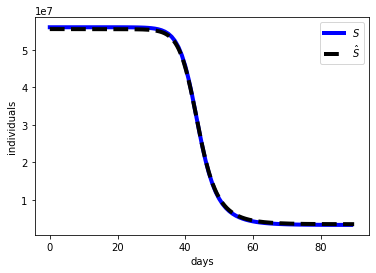

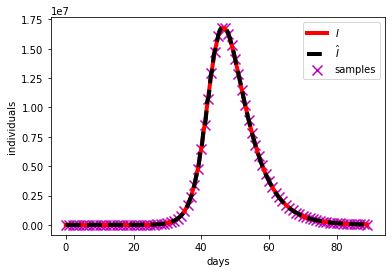

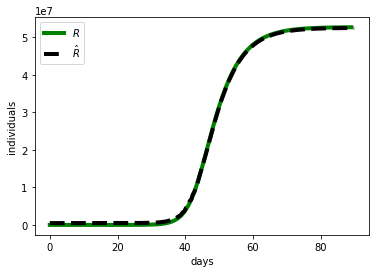

In [ ]:
# Get predictions
# 获取 joint 模型在测试时间上的 S/I/R 预测结果
# 预测值仍是缩放变量，绘图时乘以 C 还原到人数尺度
S_pred_test = Ss.eval(m, t_test_sc)
I_pred_test = Is.eval(m, t_test_sc)
R_pred_test = Rs.eval(m, t_test_sc)

# Plot results
plt.plot(t_data, S_data, c='b',linewidth=4)
plt.plot(t_test,S_pred_test*C, '--', c='k',linewidth=4)
plt.xlabel('days')
plt.ylabel('individuals')
plt.legend(['$S$', '$\hat{S}$'])
plt.show()

plt.plot(t_data,I_data, c='r', linewidth=4)
plt.plot(t_test,I_pred_test*C, '--', c='k', linewidth=4)
if weekly: plt.scatter(t_data[::7],I_obs[::7], marker='x', c='m', s=100)
else: plt.scatter(t_data,I_obs, marker='x', c='m', s=100)
plt.xlabel('days')
plt.ylabel('individuals')
plt.legend(['$I$','$\hat{I}$','samples'])
plt.show()

plt.plot(t_data, R_data, c='g',linewidth=4)
plt.plot(t_test,R_pred_test*C, '--', c='k',linewidth=4)
plt.xlabel('days')
plt.ylabel('individuals')
plt.legend(['$R$', '$\hat{R}$'])
plt.show()

In [ ]:
# Evaluate errors
# 计算相对 L2 误差，并评估 Beta 的识别误差
# 相对误差形式为 ||u-u_hat||_2 / ||u||_2；Beta 在本 case 中是常数，因此取 beta_pred[0]
S_pred = Ss.eval(m, t_data_sc)*C
I_pred = Is.eval(m, t_data_sc)*C
R_pred = Rs.eval(m, t_data_sc)*C
beta_pred = Beta.eval(m, t_data_sc)

S_err = np.linalg.norm(S_data-S_pred,2)/np.linalg.norm(S_data,2)
I_err = np.linalg.norm(I_data-I_pred,2)/np.linalg.norm(I_data,2)
R_err = np.linalg.norm(R_data-R_pred,2)/np.linalg.norm(R_data,2)
beta_err = abs(beta_pred[0]-beta)/beta

print(f'S error: {S_err:.3e}')
print(f'I error: {I_err:.3e}')
print(f'R error: {R_err:.3e}')
print(f'Beta error: {beta_err:.3e}')

Input and output dimensions need re-adjustment for post-processing.
S error: 9.416e-03
I error: 2.542e-03
R error: 1.088e-02
Beta error: 2.186e-02


In [ ]:
# Save training history and model
# 保存 joint 阶段的训练历史和模型权重
# h.history 包含 loss 和 Beta 随 epoch 的变化，可用于后续分析
with open('hJoint.txt', 'wb') as myFile:
    pickle.dump(h.history, myFile)
myFile.close()

m.save_weights('mJoint.hdf5')